## Setup, Loading Data and CDFs

In [1]:
DATA_NAME = 'syntheticMRI3D-full' 
TRANSFORM = 'wavelet'
CHANNEL = 'dad'

In [2]:
path_list = DATA_NAME.split("-") + TRANSFORM.split("-")
if CHANNEL:
    path_list.append(CHANNEL)
print(f"Name the notebook:\n{'_'.join(path_list[::-1])}.ipynb")
FULL_DATA_NAME='-'.join(path_list)

Name the notebook:
dad_wavelet_full_syntheticMRI3D.ipynb


In [3]:
import git
from pathlib import Path
import os

ROOT_DIR = Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
CWD = os.path.join(ROOT_DIR, "results", "case-studies", *path_list)

assert CWD == os.getcwd()
Path(os.path.join(CWD, "CSVs")).mkdir(exist_ok=True)
Path(os.path.join(CWD, "plots")).mkdir(exist_ok=True)
Path(os.path.join(CWD, "cache")).mkdir(exist_ok=True)

GROUP = 'layer' if TRANSFORM.split("-")[0] == 'wavelet' else ('band' if TRANSFORM.split("-")[0] == 'fourier' else 'error')
RERUN = False
SKIP_OPTIMIZE_STEP = False
CWD

'c:\\Users\\yashd\\Desktop\\hierarchical-bayesian-model-validation\\results\\case-studies\\syntheticMRI3D\\full\\wavelet\\dad'

In [4]:
os.chdir(os.path.join(ROOT_DIR, "utilities"))
from testing import * # If MATLAB is not installed, open utilities and set to False
from plotting import *
os.chdir(CWD)
np.random.seed(0)

In [5]:
group_data_map = pd.read_pickle(os.path.join(ROOT_DIR, "transformed-data", f'{FULL_DATA_NAME}.pickle'))
group_total_samples = pd.read_pickle(os.path.join(ROOT_DIR, "transformed-data", f'{FULL_DATA_NAME}-size.pickle'))

In [6]:
if 'fourier' in TRANSFORM:
    GROUPS = np.arange(2, sorted(group_data_map)[-1] + 1)[::3]
elif 'wavelet' in TRANSFORM:
    GROUPS = np.arange(2, sorted(group_data_map)[-1] + 1)
GROUPS=[8]

cdfs_dir = os.path.join(ROOT_DIR, "results", "CDFs")
cdfs_list = sorted([os.path.join(cdfs_dir, i) for i in os.listdir(cdfs_dir)])
all_cdfs = combine_pickles(cdfs_list[0])
for cdf_dir in cdfs_list[:6]: # TODO For quick testing purposes. Currently excluding 20000 CDFs. Use cdfs_list[5:6] to access CDFs/_test
    all_cdfs = all_cdfs | combine_pickles(cdf_dir)
    
# group_data_map = {g : group_data_map[g][::100] for g in GROUPS} # TODO For quick testing purposes
group_total_samples

{2: 0, 3: 564, 4: 22538, 5: 296776, 6: 2880648, 7: 25362406, 8: 213093688}

Running 12760 CDFs


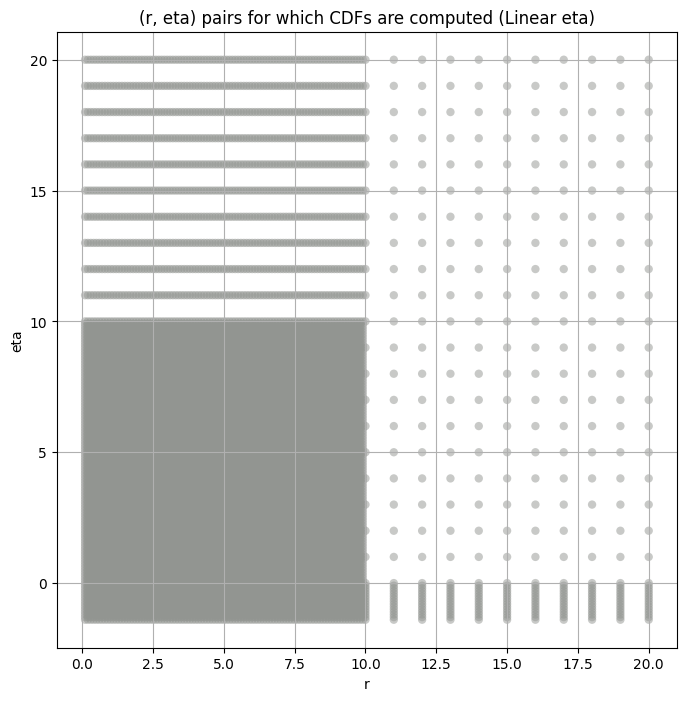

,"(r,eta),cdf",r,eta,cdf,variance,kurtosis
0,"((0.1, -1.4), <scipy.interpolate._fitpack2.Int...",0.1,-1.4,<scipy.interpolate._fitpack2.InterpolatedUniva...,3.628800e+06,554265.000000
1,"((0.1, -1.3), <scipy.interpolate._fitpack2.Int...",0.1,-1.3,<scipy.interpolate._fitpack2.InterpolatedUniva...,3.991680e+07,96192.272727
2,"((0.1, -1.2), <scipy.interpolate._fitpack2.Int...",0.1,-1.2,<scipy.interpolate._fitpack2.InterpolatedUniva...,2.395008e+08,29390.000000
3,"((0.1, -1.1), <scipy.interpolate._fitpack2.Int...",0.1,-1.1,<scipy.interpolate._fitpack2.InterpolatedUniva...,1.037837e+09,11997.692308
4,"((0.1, -1.0), <scipy.interpolate._fitpack2.Int...",0.1,-1.0,<scipy.interpolate._fitpack2.InterpolatedUniva...,3.632429e+09,5874.890110


In [7]:
warnings.filterwarnings('ignore', category=RuntimeWarning)

all_cdfs_df = create_kurt_var_ksstat_df(all_cdfs)
fine_cdfs_df = all_cdfs_df.copy()
all_cdfs_df = all_cdfs_df[(np.round(all_cdfs_df['r'], 1) == all_cdfs_df['r']) & (np.round(all_cdfs_df['eta'], 1) == all_cdfs_df['eta'])]
all_cdfs_df = all_cdfs_df.reset_index(drop=True)
all_cdfs = {x[0] : x[1] for x in all_cdfs_df["(r,eta),cdf"]}
                                             
var_values_dict = dict()
kurt_values_dict = dict()
master_df = pd.DataFrame(columns=[GROUP]).set_index(GROUP)
temp_cdf = all_cdfs_df
print(f"Running {all_cdfs_df.shape[0]} CDFs")
create_scatter_plot(all_cdfs_df);
all_cdfs_df.head()

## Bootstrapping the Variance and Kurtosis

In [8]:
n_bootstrap = int(1e5) # TODO For quick testing purposes
bootstrap_size = int(1e4) # TODO For quick testing purposes
ci = 0.99

In [9]:
bootstrap_path = Path(os.path.join(CWD, "CSVs", f'initial_grid_bootstrap{n_bootstrap}_{bootstrap_size}_ci{ci}.csv'))
master_df_var_kurt_path = Path(os.path.join(CWD, "CSVs", f'initial_grid_bootstrap{n_bootstrap}_{bootstrap_size}_ci{ci}.csv'))

if RERUN or not master_df_var_kurt_path.exists(): # TODO For quick testing purposes
    for group in GROUPS:
        print(f'{GROUP.capitalize()} {group}')
        obs_var, var_lower, var_upper, var_values_dict[group] = bootstrap_metric(group_data_map[group], 
                                                                                n_bootstrap=n_bootstrap, 
                                                                                bootstrap_size=min(group_data_map[group].size, bootstrap_size), 
                                                                                metric= np.var, 
                                                                                ci=ci)
        obs_kurt, kurt_lower, kurt_upper, kurt_values_dict[group] = bootstrap_metric(group_data_map[group], 
                                                                                    n_bootstrap=n_bootstrap, 
                                                                                    bootstrap_size=min(group_data_map[group].size, bootstrap_size), 
                                                                                    metric= stats.kurtosis, ci=ci)  
        master_df.loc[group, 'obs_var'], master_df.loc[group, 'var_lower'], master_df.loc[group, 'var_upper'] = obs_var, var_lower, var_upper
        master_df.loc[group, 'obs_kurt'], master_df.loc[group, 'kurt_lower'], master_df.loc[group, 'kurt_upper'] = obs_kurt, kurt_lower, kurt_upper
        master_df.loc[group, 'total_samples'] = group_total_samples[group]

    master_df.to_csv(os.path.join(CWD, "CSVs", f'initial_grid_bootstrap{n_bootstrap}_{bootstrap_size}_ci{ci}.csv'))

master_df = pd.read_csv(master_df_var_kurt_path, index_col=GROUP)
var_kurt_df = pd.read_csv(bootstrap_path, index_col=GROUP)
master_df

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples
layer,,,,,,,
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,1.177849e+06,996756.250000,1.369790e+06,0.133331,-0.296798,0.629724,564.0
4,5.544239e+05,530262.940000,5.787912e+05,0.887641,0.729112,1.060642,22538.0
5,8.563575e+04,80896.880000,9.057298e+04,2.790587,2.209590,3.619065,296776.0
6,1.720976e+04,15558.705000,1.896846e+04,12.881204,10.923777,14.954548,2880648.0
7,1.438634e+03,1291.273300,1.598209e+03,15.234228,12.320395,18.880985,25362406.0
8,5.583345e+01,46.389084,8.071121e+01,133.449080,13.199213,557.197800,213093688.0


## Initial Grid Search and Hypothesis Test Plots

In [10]:
EXCLUDE_CUTOFFS = [0, 25, 50, 75, 100, 150, 200, 250, 300, 350, 500] # TODO For quick testing purposes
SCALE_CAP = 1e5

In [11]:
augmented_var_df_path = Path(os.path.join(CWD, "CSVs", "augmented_var_df.csv"))
augmented_var_df = var_kurt_df[['obs_var']].copy()
augmented_var_df
for val in EXCLUDE_CUTOFFS:
    temp_arr = []
    for group in GROUPS:
        if val != 0:
            temp_arr.append(np.var(group_data_map[group][val:-val]))
        else:
            temp_arr.append(np.var(group_data_map[group]))

    augmented_var_df[f"var_exclude_{val}"] = temp_arr
augmented_var_df

ValueError: Length of values (1) does not match length of index (7)

In [14]:
master_df_combo_path = Path(os.path.join(CWD, "CSVs", "master_df_combo.csv"))
rEtaKsstats_dict_path = Path(os.path.join(CWD, "cache", "rEtaKsstats_dict.pickle"))

rEtaKsstats_dict = dict()

if RERUN or not master_df_combo_path.exists():
    sorted_params = sorted(all_cdfs)
    ksstats_dict = dict()

    for i, group in enumerate(GROUPS): # TODO For quick testing purposes
        print(f"####\n{GROUP.capitalize()} ", group)
        sample = group_data_map[group]
        if len(sample) == 0:
            continue
        group_cdfs_df = all_cdfs_df.copy()
        master_df.loc[group, 'kstest_stat_initial'] = 1

        for j in range(len(EXCLUDE_CUTOFFS)):

            exclude_cutoff = EXCLUDE_CUTOFFS[j]
            exclude_cutoff = int(exclude_cutoff)

            if exclude_cutoff == 0:
                augmented_var = np.var(group_data_map[group]) 
            else:
                augmented_var = np.var(group_data_map[group][exclude_cutoff:-exclude_cutoff])
                if augmented_var == np.var(group_data_map[group]):
                    continue 
                
            group_cdfs_df['scale'] = np.clip((augmented_var / group_cdfs_df['variance']), 0,  SCALE_CAP)
            ksstats, initial_param, min_stat = gridsearch(sample, all_cdfs, debug=True, scales=group_cdfs_df['scale'])
            augmented_var_df.loc[group, f"kstest_stat_{exclude_cutoff}"] = min_stat
            group_cdfs_df[f'ksstat_exclude_{exclude_cutoff}'] = ksstats
            
            print(group, exclude_cutoff, min_stat, augmented_var)
            
            if (min_stat < master_df.loc[group, 'kstest_stat_initial']) and not np.isclose(min_stat, master_df.loc[group, 'kstest_stat_initial'], 1e-6):
                inital_min_stat = min_stat
                inital_best_param = initial_param
                master_df.loc[group, 'kstest_stat_initial'] = min_stat
                initial_scale = group_cdfs_df.loc[(group_cdfs_df["r"] ==  initial_param[0]) & (group_cdfs_df["eta"] ==  initial_param[1])]["scale"].iloc[0]
                master_df.loc[group, 'initial_r'], master_df.loc[group, 'initial_eta'] = initial_param
                master_df.loc[group, 'initial_scale'] = initial_scale
                master_df.loc[group, 'initial_exclude_cutoff'] = exclude_cutoff
                master_df.loc[group, 'best_augmented_var'] = augmented_var
        
        ksstats = group_cdfs_df[f"ksstat_exclude_{int(master_df.loc[group, 'initial_exclude_cutoff'])}"]
            
        print(f"Number of samples: {sample.size}, Without approximation : {master_df.loc[group, 'total_samples']}")
        
        cutoff = stats.kstwo(n=master_df.loc[group, 'total_samples']).isf(0.05)
        master_df.loc[group, 'kstest_stat_cutoff_0.05'] = cutoff

        best_scales = np.clip((master_df.loc[group, 'best_augmented_var'] / group_cdfs_df['variance']), 0,  SCALE_CAP)

        group_cdfs_df['variance'] = group_cdfs_df['variance'] * best_scales
        group_cdfs_df['kurtosis'] = group_cdfs_df['kurtosis'] * best_scales

        group_cdfs_df = add_tests_to_df(cdfs_df = group_cdfs_df, group = group, var_kurt_df = master_df, ksstats = ksstats).sort_values(['r', 'eta'])

        group_dict = {'r' : group_cdfs_df['r'], 'eta' : group_cdfs_df['eta']}
        group_dict.update({f'ksstat_exclude_{exclude_cutoff}' : group_cdfs_df[f'ksstat_exclude_{exclude_cutoff}'] for exclude_cutoff in EXCLUDE_CUTOFFS[:j+1]})
        rEtaKsstats_dict[group] = group_dict

        cols = ['pass_var', 'pass_kstest', 'pass_kurt']

        fig = combo_test_plot(group_cdfs_df, cols, 
                            plot_name=f"{GROUP.capitalize()} {group}: {', '.join([col[5:].capitalize() for col in cols])} Exclude:{master_df.loc[group, 'initial_exclude_cutoff']}", 
                            target_var = None,
                            best_param = inital_best_param,
                            best_ksstat=inital_min_stat
                            )
        
        fig.figure.savefig(os.path.join(CWD, "plots", f"full_grid_search_combo_plot_layer{group}.jpg"), bbox_inches = 'tight', dpi=100)

        # Optional: 
        # Create plots of bootstrapped variance and kurtosis for varying confidence intervals
        # fig_var = create_ci_scatter_plot(group_cdfs_df, var_values_dict, metric='variance', group=group)
        # fig_kurt = create_ci_scatter_plot(group_cdfs_df, kurt_values_dict, metric='kurtosis', group=group)

        # fig_var.savefig(os.path.join(CWD, "plots", f"ci_scatter_variance_{GROUP}_{group}_bootstrap{n_bootstrap}.jpg"), bbox_inches='tight')
        # plt.close(fig_var)
        # fig_kurt.savefig(os.path.join(CWD, "plots", f"ci_scatter_variance_{GROUP}_{group}_bootstrap{n_bootstrap}.jpg"), bbox_inches='tight')
        # plt.close(fig_kurt)

    master_df.to_csv(master_df_combo_path)
    pd.to_pickle(rEtaKsstats_dict, rEtaKsstats_dict_path)
    augmented_var_df.to_csv(augmented_var_df_path)

augmented_var_df = pd.read_csv(augmented_var_df_path, index_col=GROUP)
master_df = pd.read_csv(master_df_combo_path, index_col=GROUP)
rEtaKsstats_dict = pd.read_pickle(rEtaKsstats_dict_path)
master_df

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples,kstest_stat_initial,initial_r,initial_eta,initial_scale,initial_exclude_cutoff,best_augmented_var,kstest_stat_cutoff_0.05
layer,,,,,,,,,,,,,,
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.177849e+06,996756.250000,1.369790e+06,0.133331,-0.296798,0.629724,564.0,0.018039,0.6,5.3,1.964442e+04,0.0,1.177849e+06,0.056882
4,5.544239e+05,530262.940000,5.787912e+05,0.887641,0.729112,1.060642,22538.0,0.030388,0.5,0.0,4.620199e+04,0.0,5.544239e+05,0.009039
5,8.563575e+04,80896.880000,9.057298e+04,2.790587,2.209590,3.619065,296776.0,0.002095,0.7,0.0,2.503724e+04,25.0,8.428304e+04,0.002492
6,1.720976e+04,15558.705000,1.896846e+04,12.881204,10.923777,14.954548,2880648.0,0.005503,0.1,3.3,8.733964e-14,250.0,1.368634e+04,0.000800
7,1.438634e+03,1291.273300,1.598209e+03,15.234228,12.320395,18.880985,25362406.0,0.003644,0.1,1.8,2.436107e-13,75.0,1.300777e+03,0.000270
8,5.583345e+01,46.389084,8.071121e+01,133.449080,13.199213,557.197800,213093688.0,0.002604,0.1,1.7,1.192198e-14,25.0,4.850154e+01,0.000093


## Optimization

In [15]:
master_df['kstest_stat_best'] = master_df['kstest_stat_initial']
master_df[f'best_r'] = master_df['initial_r']
master_df[f'best_eta'] = master_df['initial_eta']
master_df[f'best_scale'] = master_df['initial_scale']
master_df[f'best_exclude_cutoff'] = master_df['initial_exclude_cutoff']

In [16]:
master_df_optimized_path = Path(os.path.join(CWD, "CSVs", 'master_df_optimized.csv'))

NUM_ITERS = dict(zip(GROUPS, [1]*len(GROUPS))) # By default, does one iteration per group
NUM_SAMPLES_OPTIMIZE = 2000
EXCLUDE_CUTOFFS_OPTIMIZE = np.arange(100, -101, -25)

if RERUN or not master_df_optimized_path.exists():

    if SKIP_OPTIMIZE_STEP:

        master_df['kstest_stat_best'] = master_df['kstest_stat_initial']
        master_df[f'best_r'] = master_df['initial_r']
        master_df[f'best_eta'] = master_df['initial_eta']
        master_df[f'best_scale'] = master_df['initial_scale']
        master_df[f'best_exclude_cutoff'] = master_df['initial_exclude_cutoff']

    else:
        for group in GROUPS: # TODO For quick testing purposes
            print(f"{GROUP.capitalize()} {group}")
            master_df.loc[group, 'kstest_stat_best'] = master_df.loc[group, 'kstest_stat_initial']
            master_df.loc[group, 'best_r'] = master_df.loc[group, 'initial_r']
            master_df.loc[group, 'best_eta'] = master_df.loc[group, 'initial_eta']
            master_df.loc[group, 'best_scale'] = master_df.loc[group, 'initial_scale']

            sample = group_data_map[group]
            if len(sample) == 0:
                continue
            initial_r, initial_eta = master_df.loc[group, 'initial_r'], master_df.loc[group, f'initial_eta']
            eps = 0.5
            group_cdfs_df = fine_cdfs_df[(np.abs(master_df.loc[group, 'initial_r'] - fine_cdfs_df['r']) < eps) & 
                                        (np.abs(master_df.loc[group, 'initial_eta'] - fine_cdfs_df['eta']) < eps)].reset_index(drop=True)
            group_cdfs = {x[0]:x[1] for x in group_cdfs_df['(r,eta),cdf']}

            for adjust_exclude_cutoff in EXCLUDE_CUTOFFS_OPTIMIZE: # -50, -25, 0, 25, 50
                
                exclude_cutoff = int(max(0, adjust_exclude_cutoff + master_df.loc[group, 'initial_exclude_cutoff']))
                
                if exclude_cutoff == 0:
                    augmented_var = np.var(group_data_map[group])
                else:
                    augmented_var = np.var(group_data_map[group][exclude_cutoff:-exclude_cutoff])                       

                group_cdfs_df['scale'] = np.clip((augmented_var / group_cdfs_df['variance']), 0,  SCALE_CAP)
                ksstats, initial_param, min_stat = gridsearch(sample, group_cdfs, debug=True, scales=group_cdfs_df['scale'])
                
                cutoff_label = generate_cutoff_label(adjust_exclude_cutoff)

                augmented_var_df.loc[group, f"kstest_stat_{cutoff_label}"] = min_stat
                group_cdfs_df[f'ksstat_exclude_{cutoff_label}'] = ksstats
                
                print(f"{GROUP} {group}, {master_df.loc[group, 'initial_exclude_cutoff']} + {adjust_exclude_cutoff} = {exclude_cutoff}, ksstat: {min_stat}, var: {augmented_var}")
                best_adjust = 0

                if min_stat < master_df.loc[group, 'kstest_stat_best']:

                    inital_min_stat = min_stat
                    inital_best_param = initial_param
                    master_df.loc[group, 'kstest_stat_best'] = min_stat
                    initial_scale = group_cdfs_df.loc[(group_cdfs_df["r"] ==  initial_param[0]) & (group_cdfs_df["eta"] ==  initial_param[1])]["scale"].iloc[0]
                    master_df.loc[group, 'best_r'], master_df.loc[group, 'best_eta'] = initial_param
                    master_df.loc[group, 'best_scale'] = initial_scale
                    master_df.loc[group, 'best_exclude_cutoff'] = exclude_cutoff
                    master_df.loc[group, 'best_augmented_var'] = augmented_var
                    augmented_var_df.loc[group, 'best_augmented_var'] = augmented_var
                    best_adjust = adjust_exclude_cutoff

                if exclude_cutoff == 0:
                    break

            cutoff_label = generate_cutoff_label(best_adjust)
            ksstats = group_cdfs_df[f"ksstat_exclude_{cutoff_label}"]
            
            print(f"Number of samples: {sample.size}, Without approximation : {master_df.loc[group, 'total_samples']}")
            
            cutoff = stats.kstwo(n=master_df.loc[group, 'total_samples']).isf(0.05)
            master_df.loc[group, 'kstest_stat_cutoff_0.05'] = cutoff

            best_scales = np.clip((master_df.loc[group, 'best_augmented_var'] / group_cdfs_df['variance']), 0,  SCALE_CAP)

            group_cdfs_df['variance'] = group_cdfs_df['variance'] * best_scales
            group_cdfs_df['kurtosis'] = group_cdfs_df['kurtosis'] * best_scales

            group_cdfs_df = add_tests_to_df(cdfs_df = group_cdfs_df, group = group, var_kurt_df = master_df, ksstats = ksstats).sort_values(['r', 'eta'])

            group_dict = rEtaKsstats_dict[group]
            group_dict.update({'r_optimize' : group_cdfs_df['r'], 'eta_optimize' : group_cdfs_df['eta'], f'ksstat_exclude_{cutoff_label}' : ksstats})
            rEtaKsstats_dict[group] = group_dict

            cols = ['pass_var', 'pass_kstest', 'pass_kurt']
            fig = combo_test_plot(group_cdfs_df, cols, 
                                plot_name=f"{GROUP.capitalize()} {group} zoomed in: {', '.join([col[5:].capitalize() for col in cols])}  Exclude:{master_df.loc[group, 'best_exclude_cutoff']}",
                                best_param=(master_df.loc[group, 'best_r'], master_df.loc[group, f'best_eta']),
                                best_ksstat=master_df.loc[group, 'kstest_stat_best'])
            fig.figure.savefig(os.path.join(CWD, "plots", f"optimized_full_grid_search_combo_plot_layer{group}.jpg"), bbox_inches = 'tight', dpi=100)
            
    master_df['n_pval_0.05'] = master_df.apply(lambda row : find_n_fixed_pval_stat(row.loc['kstest_stat_best'], row.loc['total_samples']), axis = 1)    
    master_df[['total_samples', 'initial_r', 'initial_eta', 'kstest_stat_initial', 'initial_exclude_cutoff', 'best_r', 'best_eta', 'best_scale', 'kstest_stat_best', 'best_exclude_cutoff', 'n_pval_0.05']].to_csv(os.path.join(CWD, "CSVs", 'optimized_params.csv'))
    master_df.to_csv(os.path.join(CWD, "CSVs", 'master_df_optimized.csv'))
    augmented_var_df.to_csv(augmented_var_df_path)
    pd.to_pickle(rEtaKsstats_dict, rEtaKsstats_dict_path)

rEtaKsstats_dict = pd.read_pickle(rEtaKsstats_dict_path)
master_df = pd.read_csv(master_df_optimized_path, index_col = GROUP)
augmented_var_df = pd.read_csv(augmented_var_df_path, index_col = GROUP)
master_df

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples,kstest_stat_initial,initial_r,initial_eta,initial_scale,initial_exclude_cutoff,best_augmented_var,kstest_stat_cutoff_0.05,kstest_stat_best,best_r,best_eta,best_scale,best_exclude_cutoff,n_pval_0.05
layer,,,,,,,,,,,,,,,,,,,,
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
3,1.177849e+06,996756.250000,1.369790e+06,0.133331,-0.296798,0.629724,564.0,0.018039,0.6,5.3,1.964442e+04,0.0,1.177849e+06,0.056882,0.018037,0.64,4.9,3.091389e+04,0.0,5416
4,5.544239e+05,530262.940000,5.787912e+05,0.887641,0.729112,1.060642,22538.0,0.030388,0.5,0.0,4.620199e+04,0.0,5.544239e+05,0.009039,0.029468,0.55,-0.1,7.891671e+04,0.0,2112
5,8.563575e+04,80896.880000,9.057298e+04,2.790587,2.209590,3.619065,296776.0,0.002095,0.7,0.0,2.503724e+04,25.0,8.563575e+04,0.002492,0.001933,0.55,0.3,8.111061e+03,0.0,500809
6,1.720976e+04,15558.705000,1.896846e+04,12.881204,10.923777,14.954548,2880648.0,0.005503,0.1,3.3,8.733964e-14,250.0,1.393158e+04,0.000800,0.005206,0.10,3.2,1.078205e-13,225.0,67515
7,1.438634e+03,1291.273300,1.598209e+03,15.234228,12.320395,18.880985,25362406.0,0.003644,0.1,1.8,2.436107e-13,75.0,1.300777e+03,0.000270,0.003512,0.09,2.2,4.297988e-16,75.0,148606
8,5.583345e+01,46.389084,8.071121e+01,133.449080,13.199213,557.197800,213093688.0,0.002604,0.1,1.7,1.192198e-14,25.0,5.583345e+01,0.000093,0.001932,0.08,2.1,2.771022e-20,0.0,499996


## Comparing Empirical and Computed CDF/PDF

In [50]:
FONT_SIZE = 30

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams.update({'legend.fontsize': FONT_SIZE, 'legend.markerscale': 2.0})


2.7710223965409983e-20

In [85]:
group = 8
group_info = master_df.loc[group]
best_r = group_info['best_r']
best_eta = group_info['best_eta']
best_scale = group_info['best_scale']
sample = group_data_map[group]
params = (best_r, best_eta, best_scale) 
log_scale = True
group = group
distro = 'gengamma'
log_scale = True
n_samples=2000
interval = None
provided_loc = None
group=None, 
percent_excluded=0.1
plot_hist=True
bw = 0.05
bw_log = 0.05
binwidth = None

Params: 0.08, 2.1
Chebyshev bound: 236.2910288550611
Tail samples: 200


  0%|          | 0/1000 [00:00<?, ?it/s]

Maximum Diff in y-values: 0.023221372041578203
First CDF value: 1.4269719741835093e-06
Last CDF value: 0.9999985730280259
Tail bound: 0.001
5.42


C:\Users\yashd\AppData\Local\Temp\ipykernel_39556\3711785987.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend().set_visible(False)
C:\Users\yashd\AppData\Local\Temp\ipykernel_39556\3711785987.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend().set_visible(False)


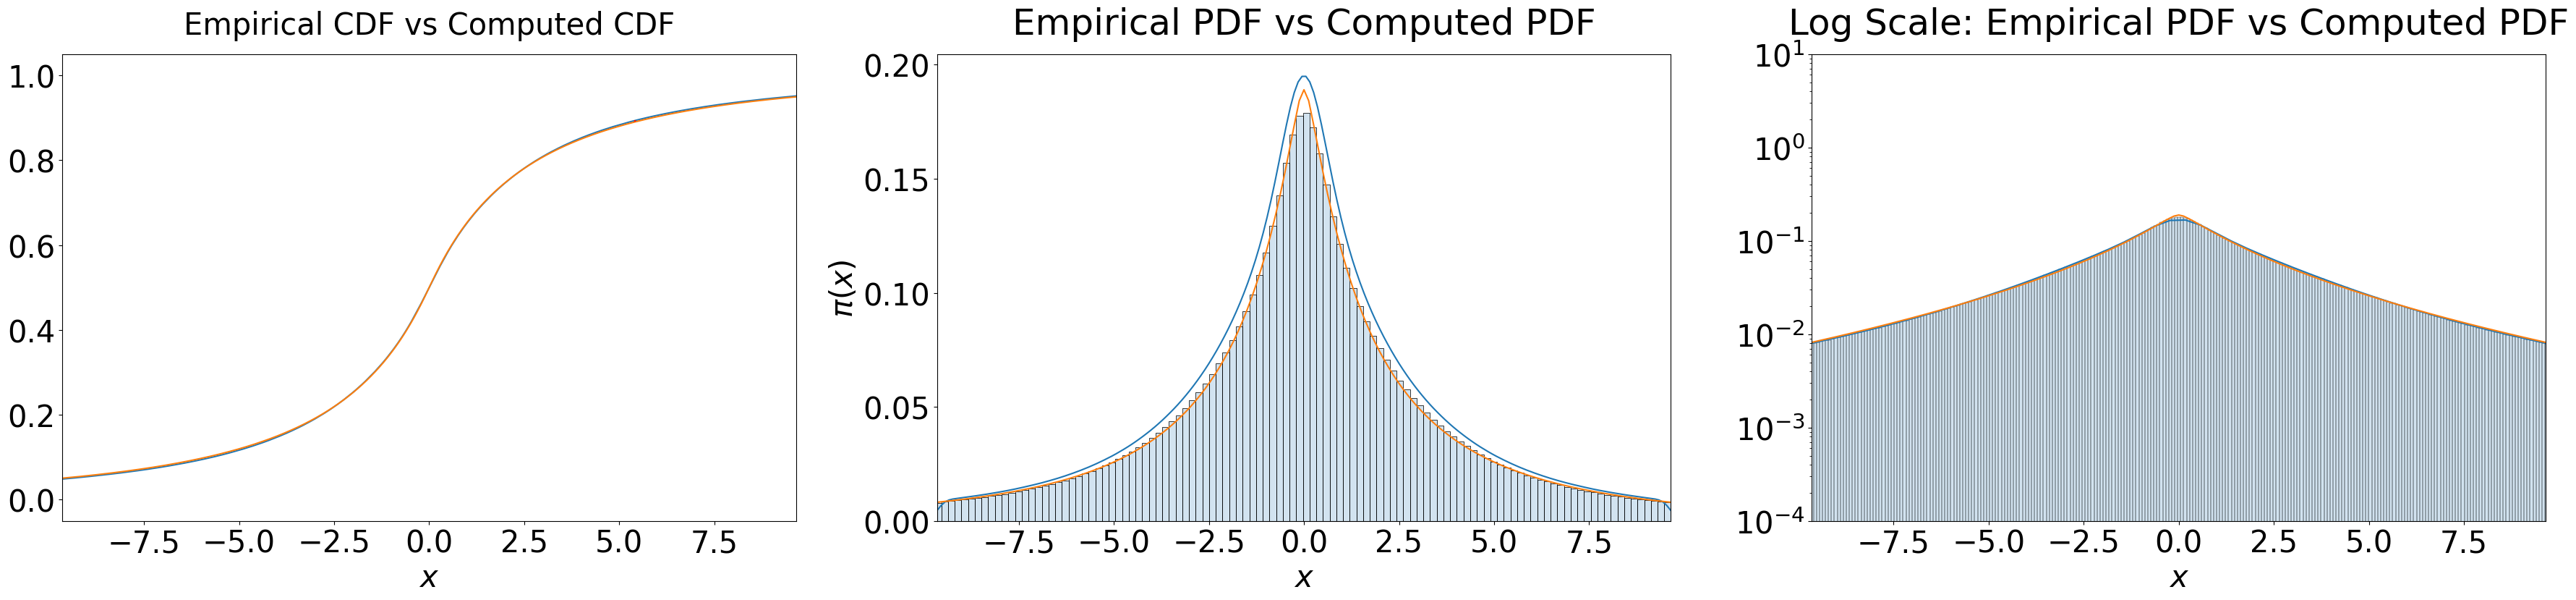

In [ ]:
if len(sample) > 0:
    lower_bound = np.percentile(sample, percent_excluded/2)
    upper_bound = np.percentile(sample, (100-percent_excluded/2))
    original_sample = sample
    sample = sample[(sample > lower_bound) & (sample < upper_bound)]
    sample = np.sort(sample)
    n = len(sample)
    if interval is None:
        interval = (np.percentile(sample, 5), np.percentile(sample, 95))
    xs = np.linspace(max(interval[0], np.min(sample)), min(np.max(sample), interval[1]), 2000000)

if distro == 'gengamma':
    if len(params) == 3:
        r, eta, scale = params
    else:
        r, eta = params
        scale = 1
    xs_pdf, null_cdf = compute_prior_cdf(r=r, eta=eta, scale = scale, n_samples=n_samples, enforce_assert=False, debug=True, return_xs=True)
    null_pdf = null_cdf.derivative()(xs_pdf)
    
elif distro == 'gaussian' or distro == 'normal':
    null_cdf = stats.norm(scale=params).cdf
    xs_pdf = np.linspace(-30, 30, 10000)
    null_pdf = stats.norm(scale=params).pdf(xs)
elif distro == 'laplace':
    null_cdf = stats.laplace(scale=params).cdf
    xs_pdf = np.linspace(-30, 30, 10000)
    null_pdf = stats.laplace(scale=params).pdf(xs_pdf)

if log_scale:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(36, 9), sharex=True)
    # fig.suptitle(f'{f"{GROUP_NAME} {group}" if group else ""} Empirical CDF vs Computed CDF \n (r={r}, eta={eta}, scale={np.format_float_scientific(scale, 2)})', fontsize=fontsize)
    if interval:
        ax1.set_xlim(left = interval[0], right = interval[1])

    if len(sample) > 0:
        ax1.plot(sample, np.arange(1, n+1)/n, label='Empirical CDF')
        result = stats.ks_1samp(original_sample, null_cdf)
        distance = result.statistic
        location = result.statistic_location
        emp_cdf_at_loc = np.searchsorted(original_sample, location, side='right') / n
        computed_cdf_at_loc = null_cdf(location)
        ax1.plot(xs, null_cdf(xs), label='Computed CDF')
        location = np.round(location, 2)
        print(location)
        ax1.vlines(location, emp_cdf_at_loc, computed_cdf_at_loc, linestyles='--', color='xkcd:bright red', label=f'KS Stat: {np.round(distance, 4)} at x={5.35}')
    else:
        ax1.plot(xs_pdf, null_cdf(xs_pdf))

    if len(sample) > 0 and provided_loc:
        emp_cdf_at_provided_loc = np.searchsorted(original_sample, provided_loc, side='right') / n
        computed_cdf_at_provided_loc = null_cdf(provided_loc)
        ax1.vlines(provided_loc, emp_cdf_at_provided_loc, computed_cdf_at_provided_loc, linestyles='--', color='xkcd:shamrock green')

    if interval:
        ax2.set_xlim(left = interval[0], right = interval[1])
    
    if len(sample)>0:
        sns.kdeplot(sample[(sample >= interval[0]) & (sample <= interval[1])], bw_method = bw, ax=ax2)
        if plot_hist:
            sns.histplot(sample, ax=ax2, binwidth = binwidth, stat='density', alpha=0.2)
    ax2.plot(xs_pdf, null_pdf)
    
    if interval:
        ax3.set_xlim(left = interval[0], right = interval[1])
    ax3.set_ylim(bottom = 10**-4, top=10)
    
    if len(sample)>0:
        sns.kdeplot(ax = ax3, x = sample, bw_method = bw_log, log_scale=[False, True])
        if plot_hist:
            sns.histplot(sample, ax = ax3, binwidth = binwidth, stat = "density", log=True, bins=1000, alpha=0.2, color='#1f77b4')

    ax3.plot(xs_pdf, null_pdf)
    
    if len(sample) == 0:
        ax1.set_title(f'Visualized {distro} CDF with params {params}')
        ax2.set_title(f'Visualized {distro} PDF with params {params}')
        ax3.set_title(f'Visualized {distro} PDF (log-scale) with params {params}')
    elif distro == 'gengamma':
        ax1.set_title(f'Empirical CDF vs Computed CDF', pad=20, fontsize=30)
        ax2.set_title(f'Empirical PDF vs Computed PDF', pad=20)
        ax3.set_title(f'Log Scale: Empirical PDF vs Computed PDF', pad=20)

    ax1.set_ylabel("")
    ax2.set_ylabel(r"$\pi(x)$")
    ax3.set_ylabel("")
    
    ax1.set_xlabel(r"$x$")
    ax2.set_xlabel(r"$x$")
    ax3.set_xlabel(r"$x$")

    # Set tick font size
    for ax in [ax1, ax2, ax3]:
        ax.tick_params(axis='both', which='major', labelsize=FONT_SIZE)
        ax.tick_params(axis='both', which='minor', labelsize=FONT_SIZE)

    # Hide legends
    ax1.legend().set_visible(False)
    ax2.legend().set_visible(False)
    ax3.legend().set_visible(False)

    plt.tight_layout()
    plt.show()

In [91]:
# Extract labels and handles from the figure
handles, labels = ax1.get_legend_handles_labels()
# labels = [l.replace("_", " ") for l in labels]
handles, labels

([<matplotlib.lines.Line2D at 0x22dda4ce9d0>,
 ['Empirical CDF', 'Computed CDF', 'KS Stat: 0.0025\n at x=5.35'])

C:\Users\yashd\AppData\Local\Temp\ipykernel_39556\3955703697.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


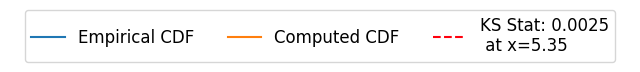

In [92]:
legend_fig = plt.figure(figsize=(8, 0.5))
legend_ax = legend_fig.add_subplot(111)
legend_ax.axis('off')  # Turn off the axis

legend_fig.legend(handles=handles, labels=labels, loc='center', ncol=6, fontsize=12)

plt.tight_layout()
plt.show()


# if SAVE_FIGS:
#     legend_save_path = os.path.join(plots_path, "failure_type_legend.jpg")
#     legend_fig.savefig(legend_save_path, dpi=600, bbox_inches='tight')

## Comparing with Gaussian and Laplace Priors

In [ ]:
def generate_func(sample, distro, *args, n_samples=200):
    if distro == 'gaussian' or distro == 'normal':
        def var_func(var):
            cdf = scipy.stats.norm(scale=var).cdf
            return compute_ksstat(sample, cdf)
        return var_func
    elif distro == 'laplace':
        def var_func(var):
            cdf = scipy.stats.laplace(scale=var).cdf
            return compute_ksstat(sample, cdf)
        return var_func
    elif distro == 't':
        def var_func(var):
            cdf = scipy.stats.t(df=2, scale=var).cdf
            return compute_ksstat(sample, cdf)
        return var_func
    elif distro == 'prior_r':
        eta = args[0]
        def r_func(r):
            cdf = compute_prior_cdf(r, eta, n_samples=n_samples)
            return compute_ksstat(sample, cdf)
        return r_func
    elif distro == 'prior_eta':
        r = args[0]
        def eta_func(eta):
            cdf = compute_prior_cdf(r, eta, n_samples=n_samples)
            return compute_ksstat(sample, cdf)
        return eta_func
    elif distro == 'prior':
        def r_eta_func(params):
            r = params[0]
            eta = params[1]
            cdf = compute_prior_cdf(r, eta, n_samples=n_samples, debug=False)
            return compute_ksstat(sample, cdf)
        return r_eta_func
    elif distro == 'prior_with_scale':
        def r_eta_scale_func(params):
            r = params[0]
            eta = params[1]
            scale = params[2]
            print(r, eta, scale)
            cdf = compute_prior_cdf(r = r, eta = eta, n_samples=n_samples, debug=False)
            return compute_ksstat(sample/ np.sqrt(scale), cdf)
        return r_eta_scale_func

    print("Please enter a valid argument for `distro`: 'gaussian', 'laplace', 'prior_r', 'prior_eta', 'prior','prior_with_scale', 't'")

In [ ]:
master_df_path = Path(os.path.join(CWD, "CSVs", 'master_df.csv'))

if RERUN or not master_df_path.exists():
    upper_bound = int(1e6)
    for group in GROUPS:
        if len(group_data_map[group]) == 0:
            continue
        norm_result = scipy.optimize.minimize_scalar(generate_func(group_data_map[group], 'gaussian'), method = 'bounded', bounds = (0, upper_bound))
        laplace_result = scipy.optimize.minimize_scalar(generate_func(group_data_map[group], 'laplace'), method = 'bounded', bounds = (0, upper_bound))
        t_result = scipy.optimize.minimize_scalar(generate_func(group_data_map[group], 't'), method = 'bounded', bounds = (0, upper_bound))
        
        master_df.loc[group, 'param_gaussian'] = round_to_sigfigs(norm_result['x'], 6)
        master_df.loc[group, 'kstest_stat_gaussian'] = round_to_sigfigs(norm_result['fun'], 6)
        master_df.loc[group, 'kstest_pval_gaussian'] = round_to_sigfigs(stats.kstwo(n=master_df.loc[group, 'total_samples']).sf(master_df.loc[group, 'kstest_stat_gaussian']), 6)

        master_df.loc[group, 'param_laplace'] = round_to_sigfigs(laplace_result['x'], 6)
        master_df.loc[group, 'kstest_stat_laplace'] = round_to_sigfigs(laplace_result['fun'], 6)
        master_df.loc[group, 'kstest_pval_laplace'] = round_to_sigfigs(stats.kstwo(n=master_df.loc[group, 'total_samples']).sf(master_df.loc[group, 'kstest_stat_laplace']), 6)

        master_df.loc[group, 'param_laplace'] = round_to_sigfigs(laplace_result['x'], 6)
        master_df.loc[group, 'kstest_stat_laplace'] = round_to_sigfigs(laplace_result['fun'], 6)
        master_df.loc[group, 'kstest_pval_laplace'] = round_to_sigfigs(stats.kstwo(n=master_df.loc[group, 'total_samples']).sf(master_df.loc[group, 'kstest_stat_laplace']), 6) 

        master_df.loc[group, 'param_t'] = round_to_sigfigs(t_result['x'], 6)
        master_df.loc[group, 'kstest_stat_t'] = round_to_sigfigs(t_result['fun'], 6)
        master_df.loc[group, 'kstest_pval_t'] = round_to_sigfigs(stats.kstwo(n=master_df.loc[group, 'total_samples']).sf(master_df.loc[group, 'kstest_stat_t']), 6) 

        master_df.loc[group, 'kstest_pval_gengamma'] = round_to_sigfigs(stats.kstwo(n=master_df.loc[group, 'total_samples']).sf(master_df.loc[group, 'kstest_stat_best']))

    master_df.to_csv(os.path.join(CWD, "CSVs", 'master_df.csv'))
    
master_df = pd.read_csv(os.path.join(CWD, "CSVs", 'master_df.csv'), index_col = GROUP)
master_df

,obs_var,var_lower,var_upper,obs_kurt,kurt_lower,kurt_upper,total_samples,kstest_stat_initial,initial_r,initial_eta,...,param_gaussian,kstest_stat_gaussian,kstest_pval_gaussian,param_laplace,kstest_stat_laplace,kstest_pval_laplace,param_t,kstest_stat_t,kstest_pval_t,kstest_pval_gengamma
layer,,,,,,,,,,,,,,,,,,,,,
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.177849e+06,996756.250000,1.369790e+06,0.133331,-0.296798,0.629724,564.0,0.018039,0.6,5.3,...,1043.29000,0.019610,9.788850e-01,913.35800,0.026586,8.100050e-01,742.21100,0.032906,5.631640e-01,9.914821e-01
4,5.544239e+05,530262.940000,5.787912e+05,0.887641,0.729112,1.060642,22538.0,0.030388,0.5,0.0,...,575.07200,0.055342,1.936030e-60,508.57400,0.029089,5.300980e-17,422.15400,0.034493,9.851790e-24,1.947706e-17
5,8.563575e+04,80896.880000,9.057298e+04,2.790587,2.209590,3.619065,296776.0,0.002095,0.7,0.0,...,242.95600,0.025084,1.174980e-162,214.89500,0.006040,7.868580e-10,170.36800,0.011226,6.473280e-33,2.170475e-01
6,1.720976e+04,15558.705000,1.896846e+04,12.881204,10.923777,14.954548,2880648.0,0.005503,0.1,3.3,...,78.50520,0.034848,0.000000e+00,70.04490,0.013012,0.000000e+00,54.60520,0.007492,6.944370e-141,3.058091e-68
7,1.438634e+03,1291.273300,1.598209e+03,15.234228,12.320395,18.880985,25362406.0,0.003644,0.1,1.8,...,19.98610,0.045314,0.000000e+00,17.84340,0.020001,0.000000e+00,13.73800,0.018020,0.000000e+00,3.403752e-272
8,5.583345e+01,46.389084,8.071121e+01,133.449080,13.199213,557.197800,213093688.0,0.002604,0.1,1.7,...,3.76004,0.049499,0.000000e+00,3.32729,0.023006,0.000000e+00,2.61078,0.021670,0.000000e+00,0.000000e+00


## Results

In [ ]:
import pandas as pd
import os
master_df = pd.read_csv(os.path.join(os.getcwd(), "CSVs", 'master_df.csv'), index_col = 0)

In [ ]:
master_df.filter(regex="kstest_stat.*")

,kstest_stat_initial,kstest_stat_cutoff_0.05,kstest_stat_best,kstest_stat_gaussian,kstest_stat_laplace,kstest_stat_t
layer,,,,,,
2,NaN,NaN,NaN,NaN,NaN,NaN
3,0.018039,0.056882,0.018037,0.019610,0.026586,0.032906
4,0.030388,0.009039,0.029468,0.055342,0.029089,0.034493
5,0.002095,0.002492,0.001933,0.025084,0.006040,0.011226
6,0.005503,0.000800,0.005206,0.034848,0.013012,0.007492
7,0.003644,0.000270,0.003512,0.045314,0.020001,0.018020
8,0.002604,0.000093,0.001932,0.049499,0.023006,0.021670


In [ ]:
master_df.filter(regex="best.*")

,best_augmented_var,kstest_stat_best,best_r,best_eta,best_scale,best_exclude_cutoff
layer,,,,,,
2,NaN,NaN,NaN,NaN,NaN,NaN
3,1.177849e+06,0.018037,0.64,4.9,3.091389e+04,0.0
4,5.544239e+05,0.029468,0.55,-0.1,7.891671e+04,0.0
5,8.563575e+04,0.001933,0.55,0.3,8.111061e+03,0.0
6,1.393158e+04,0.005206,0.10,3.2,1.078205e-13,225.0
7,1.300777e+03,0.003512,0.09,2.2,4.297988e-16,75.0
8,5.583345e+01,0.001932,0.08,2.1,2.771022e-20,0.0


In [ ]:
eng.quit()